In [2]:
import os
import sys
import numpy as np
from pathlib import Path

# Ensure project root is on sys.path so 'backtester' imports work
cwd = Path(os.getcwd())
candidates = [cwd, cwd.parent, Path("..").resolve()]
for p in candidates:
    if (p / "backtester").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
        break

print("PYTHONPATH set. Using root:", sys.path[0])

PYTHONPATH set. Using root: c:\Users\User\Desktop\Crypto strategy backtest


## Load Data

In [3]:
import pandas as pd

def load_crypto_parquet_data(coin_name: str, timeframe: str = "5m", nM: int = 54, section: str = "UTC") -> pd.DataFrame:
    df = pd.read_parquet(fr'C:\Users\User\Desktop\Crypto\{coin_name}_{timeframe}_{nM}M_{section}.parquet')
    return df
def generate_us_session_bars_info(df, include_holidays: bool = False):
    # 確保時間有時區資訊
    df['dt_ny'] = pd.to_datetime(df['dt_utc'], utc=True).dt.tz_convert('America/New_York')

    # 取日期（當地日曆）
    df['date'] = df['dt_ny'].dt.date
    df['weekday'] = df['dt_ny'].dt.day_name() 
    # 對每天依時間排序並編號
    df = df.sort_values(['date', 'dt_ny']).reset_index(drop=True)
    df['bar_index'] = df.groupby('date').cumcount() + 1  # 第幾根K線，從1開始
    if not include_holidays:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday']
    else:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    df = df.loc[df['weekday'].isin(weekday)]
    # 查看結果
    df.set_index('dt_utc', inplace=True)
    # print(df[['dt_ny', 'date', 'weekday', 'bar_index']].head(5))

    return df
def generate_allday_bars_info(df, include_holidays: bool = True):
# 確保時間有時區資訊
    df['dt_ny'] = pd.to_datetime(df['dt_utc'], utc=True).dt.tz_convert('America/New_York')

    # 取日期（當地日曆）
    df['date'] = df['dt_ny'].dt.date
    df['time'] = df['dt_ny'].dt.time
    df['weekday'] = df['dt_ny'].dt.day_name() 
    # 對每天依時間排序並編號
    df = df.sort_values(['date', 'dt_ny']).reset_index(drop=True)
    df['bar_index'] = df.groupby('date').cumcount() + 1  # 第幾根K線，從1開始
    if not include_holidays:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday']
    else:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    df = df.loc[df['weekday'].isin(weekday)]
    # 查看結果
    df.set_index('dt_utc', inplace=True)
    # print(df[['dt_ny', 'date', 'weekday', 'bar_index']].head(5))

    return df


In [4]:
coin_name = 'BTC'  # 可更改為 'ETH', 'SOL', 'BTC', 'ADA', 'PAXG' 等等
nM = 48
timeframe = "5m"
section = "UTC"

df = load_crypto_parquet_data(coin_name=coin_name, timeframe=timeframe, nM=nM, section=section)
df = generate_allday_bars_info(df, include_holidays=False)


## Split Data

In [5]:
# 分成n等分windows
def split_into_windows(df: pd.DataFrame, n_windows: int, overlap_ratio: float = 0.0) -> list[pd.DataFrame]:
    unique_dates = df.index.unique()
    n_dates = len(unique_dates)
    window_size = n_dates // n_windows
    windows = []
    end_idx = 0
    total_windows = (n_dates - window_size)//(int(window_size * (1 - overlap_ratio))) + 1 if overlap_ratio > 0 else n_windows
    for i in range(total_windows):
        start_idx = end_idx
        if i == total_windows - 1:  # 最後一個視窗包含剩餘的日期
            end_idx = n_dates
        if overlap_ratio > 0 and i > 0:
            overlap_size = int(window_size * overlap_ratio)
            start_idx -= overlap_size
        end_idx = start_idx + window_size
        window_dates = unique_dates[start_idx:end_idx]
        window_df = df[df.index.isin(window_dates)].copy()
        windows.append(window_df)
    return windows
def split_into_train_test(df: pd.DataFrame, train_pct: float = 0.7) -> tuple[pd.DataFrame, pd.DataFrame]:
    unique_dates = df.index.unique()
    n_dates = len(unique_dates)
    train_size = int(n_dates * train_pct)
    train_dates = unique_dates[:train_size]
    test_dates = unique_dates[train_size:]
    train_df = df[df.index.isin(train_dates)].copy()
    test_df = df[df.index.isin(test_dates)].copy()
    return train_df, test_df

In [6]:
splited_dfs = split_into_windows(df, n_windows=20, overlap_ratio=0)
splited_train_test_dfs = [split_into_train_test(window_df, train_pct=0.7) for window_df in splited_dfs]

## analytics

In [7]:
from backtester.models import Position, Side, ActionType, BacktestConfig, SizingEquityBase
from backtester.engine import BacktestEngine
from backtester.strategy_base import StrategyContext
from backtester.strategies.trading_range_breakout_strategy import TradingRangeBreakoutStrategy, TrandingRangeBreakoutParams
from backtester.strategies.strong_breakout_strategy import StrongBreakoutStrategy, StrongBreakoutParams
from typing import Any, Dict, List
from itertools import product
def build_param_combinations(grid: Dict[str, List[Any]]) -> List[Dict[str, Any]]:
    """
    將 param_grid 展開成所有組合，每個組合是一個 dict。
    grid 的值必須是 list/tuple 等 iterable。
    """
    keys = list(grid.keys())
    values_lists = [grid[k] for k in keys]
    combos = [dict(zip(keys, vals)) for vals in product(*values_lists)]
    return combos
def tune_strategy_params(train_df: pd.DataFrame, test_df: pd.DataFrame, param_grid: dict, best_n_params: int, engine) -> dict:
    best_params = None
    best_performance = -float('inf')
    params_combinations = build_param_combinations(param_grid)
        
    performance_list = []

    for params in params_combinations:
        strat_params = ALBreakoutPullback50pctParams(**params)
        strat = ALBreakoutPullback50pctStrategy(strat_params)
        train_result = engine.run(train_df, strat)
        performance = train_result.equity_curve.values[-1] - train_result.equity_curve.values[0]  # 總收益作為績效指標
        unique_days = train_df.index.normalize().unique()
        performance_per_day = performance / (len(unique_days))

        if performance_per_day > best_performance:
            best_performance = performance_per_day
        performance_list.append((params, performance_per_day, len(train_result.trades)))
    performance_list.sort(key=lambda x: x[1], reverse=True)
    best_params_list = performance_list[:best_n_params]

    train_vs_test_results = []
    for params, perf, n_trades in best_params_list:
        strat_params = ALBreakoutPullback50pctParams(**params)
        strat = ALBreakoutPullback50pctStrategy(strat_params)
        test_result = engine.run(test_df, strat)
        test_performance = test_result.equity_curve.values[-1] - test_result.equity_curve.values[0]
        unique_days = test_df.index.normalize().unique()
        test_performance_per_day = test_performance / (len(unique_days))
        perf_diff = test_performance_per_day - perf
        print(f"Params: {params}, Train Perf/Day: {perf}, Test Perf/Day: {test_performance_per_day}, Trades: {len(test_result.trades)}, Perf Diff: {perf_diff}")
        train_vs_test_results.append((params, perf, test_performance_per_day, perf_diff))

    return train_vs_test_results
def test_strategy_with_params(test_df: pd.DataFrame, params: dict, engine) -> Any:
    strat_params = ALBreakoutPullback50pctParams(**params)
    strat = ALBreakoutPullback50pctStrategy(strat_params)
    test_result = engine.run(test_df, strat)
    performance = test_result.equity_curve.values[-1] - test_result.equity_curve.values[0]
    unique_days = test_df.index.normalize().unique()
    performance_per_day = performance / (len(unique_days))
    return performance_per_day, test_result


#### 全資料回測

5e-05
=== Fee Rate: 0.005% | Slip bps: 0.0 ===
trades: 783
win_rate: 0.4878671775223499
profit_factor: 1.1348694016210177
sharpe_ratio: 0.9486844836447952
max_drawdown: -0.4134039123497802
mean_pnl_pct: 0.003364978695912418
median_pnl_pct: -0.007476704448245989
p10_pnl_pct: -0.031146937930986163
p90_pnl_pct: 0.04011703901252891
final profit: 38944.01591053775
  entry_time_hour         pnl                                              
                         mean           sum          max          min count
0               0 -266.507002 -25851.179215  2810.313785 -2268.195324    97
1               1 -112.476513  -8323.261992  2634.381831 -2196.177505    74
2               2   28.709929   2153.244698  2775.337259 -2140.038833    75
3               3   15.541904    839.262799  2764.530665 -2201.430528    54
4               4  -84.816151  -5258.601345  2573.416140 -2352.716273    62
5               5  394.311692  33516.493828  2674.428305 -2239.041598    85
6               6   91.741289 

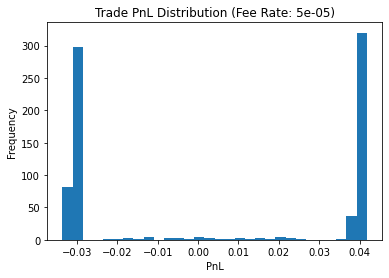

In [ ]:
from backtester.analytics import basic_metrics
from dataclasses import replace
import matplotlib.pyplot as plt
strategy_name = "strong breakout" # SBO: Strong Breakout, TRBO: Trading Range Breakout
rolling_backtest = False
if strategy_name == "strong breakout":
    cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0002, slippage_bps=0.0, conservative_intrabar=True)
    params = StrongBreakoutParams(
        BBR_thresholds =  (0.45, 0.65),
        close_loc_thresholds = (0.5, 0.7),
        push_thresholds = (0.5, 1.0, 1.5),
        overlap_thresholds = (0.3, 0.5),
        break_out_n_bars=20,

        run_score_threshold = 10.0,
        session="Asian",  # "Asian", "EU", "US", None

        max_equity_loss_pct = 3,
        min_qty = 0.001,
        min_sl_pct = 0.5,

        rr = 1.3,         # TP = SL距離 * rr
        time_exit_bars = 50,
        allow_side = Side.LONG,  # None表示雙向進出場，Side.LONG表示只做多，Side.SHORT表示只做空
        sizing_equity_base = SizingEquityBase.CURRENT,
    )
    strategy = StrongBreakoutStrategy(params)
elif strategy_name == "trading range breakout":
    cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0002, slippage_bps=0.0, conservative_intrabar=True)
    params = TrandingRangeBreakoutParams(
        trading_range_breakout_level_n=20,
        er_n=20,
        er_ma_n=5,
        er_threshold=0.09,
        bbands_n=20,
        bbands_width_pct_threshold=[1, 3],
        min_cross_bband_mid_count=0,
        min_follow_through_bars=0,

        breakout_bar_BBR_threshold=0.5,
        min_breakout_penetration_pct=0,
        
        equity_max_loss_pct=1.0,
        min_qty=0.0001,

        sl_chosen_by="TR_low",
        # tp_based_by="entry_price",
        rr=2,
        time_exit_bars=1000,
        allow_side=Side.LONG,
        sizing_equity_base=SizingEquityBase.CURRENT
    )
    strategy = TradingRangeBreakoutStrategy(params)

def core_metrics(result):
    metrics = basic_metrics(result)
    equity_curve = result.equity_curve
    trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
    trade_pnl = trades_df["pnl"]
    # pnl/equity
    trade_pnl_pct = trades_df["pnl"] / equity_curve.shift(1).reindex(trades_df["entry_time"]).values
    trades = len(trades_df)
    win_rate = metrics['win_rate']
    profit_factor = metrics['profit_factor']
    sharpe_ratio = metrics['sharpe_ratio']
    MDD = metrics['max_drawdown']
    mean_pnl_pct = trade_pnl_pct.mean()
    median_pnl_pct = trade_pnl_pct.median()
    p10_pnl_pct = trade_pnl_pct.quantile(0.1)
    p90_pnl_pct = trade_pnl_pct.quantile(0.9)
    return {
        'trades': trades,
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': MDD,
        'mean_pnl_pct': mean_pnl_pct,
        'median_pnl_pct': median_pnl_pct,
        'p10_pnl_pct': p10_pnl_pct,
        'p90_pnl_pct': p90_pnl_pct,
    }
if rolling_backtest == False:
    # for fee_rate in [0, 0.00005, 0.0001, 0.0002]:
    for fee_rate in [0.00005]:
        cfg2 = replace(cfg, fee_rate=fee_rate)
        engine = BacktestEngine(cfg2)
        print(engine.config.fee_rate)
        result = engine.run(df, strategy)
        metrics = basic_metrics(result)
        print(f"=== Fee Rate: {fee_rate*100:.3f}% | Slip bps: {engine.config.slippage_bps} ===")
        for k, v in metrics.items():
            if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio']:
                # print(f"{k}: {v}")
                pass
        for k, v in core_metrics(result).items():
            print(f"{k}: {v}")
        print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
        trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
        trade_pnl = trades_df["pnl"]
        trades_df["entry_time_hour"] = trades_df["entry_time"].dt.hour
        trade_grouped = trades_df.groupby('entry_time_hour').agg({'pnl': ['mean', 'sum', 'max', 'min', 'count']}).reset_index()
        print(trade_grouped)
        trade_pnl_pct = trades_df["pnl"] / result.equity_curve.shift(1).reindex(trades_df["entry_time"]).values

        plt.hist(trade_pnl_pct, bins=30)
        plt.title(f"Trade PnL Distribution (Fee Rate: {fee_rate})")
        plt.xlabel("PnL")
        plt.ylabel("Frequency")
        plt.show()


In [9]:
params.__dict__

{'BBR_thresholds': (0.45, 0.65),
 'close_loc_thresholds': (0.5, 0.7),
 'push_thresholds': (0.5, 1.0, 1.5),
 'overlap_thresholds': (0.3, 0.5),
 'break_out_n_bars': 20,
 'run_score_threshold': 10.0,
 'session': 'Asian',
 'max_equity_loss_pct': 3,
 'min_qty': 0.001,
 'min_sl_pct': 0.5,
 'rr': 1.3,
 'time_exit_bars': 50,
 'allow_side': <Side.LONG: 'long'>,
 'sizing_equity_base': <SizingEquityBase.CURRENT: 'current'>}

In [10]:
trades = pd.DataFrame([t.__dict__ for t in result.trades])


In [11]:
trades = pd.DataFrame([t.__dict__ for t in result.trades])
# trades.to_excel(r"C:\Users\User\Desktop\Crypto strategy backtest 分析\BreakoutPullback_pct\trades info\trades.xlsx", index=False)
trades["current_equity"] = result.equity_curve.reindex(trades["entry_time"]).values
print(trades["entry_time"][0])
trades["entry_date_time"] = trades["entry_time"].dt.tz_localize(None)
print(trades["entry_time"][0])
trades["exit_date_time"] = trades["exit_time"].dt.tz_localize(None)
trades["entry_date"] = trades["entry_date_time"].dt.date
trades["exit_date"] = trades["exit_date_time"].dt.date
# hh:mm
trades["entry_time"] = trades["entry_date_time"].dt.strftime("%H:%M")
trades["exit_time"] = trades["exit_date_time"].dt.strftime("%H:%M")
trades["pnl_gross"] = trades["pnl"]
trades["rr_gross"] = trades["pnl_gross"] / (abs(trades["sl_price"] - trades["entry_price"]) * trades["qty"])
trades["pnl_pct_gross"] = 100*trades["pnl_gross"] / trades["current_equity"]
record_fee_rate = 0.00005 # 限價單手續費
trades["fee"] = -trades["qty"] * trades["entry_price"] * record_fee_rate * 2 # 乘以2是因為進出場都要收手續費
trades["pnl"] = trades["pnl_gross"] + trades["fee"]
trades["rr"] = trades["pnl"] / (abs(trades["sl_price"] - trades["entry_price"]) * trades["qty"])
trades["total_pos_pnl_pct"] = 100*trades["pnl"] / trades["current_equity"]
trades["sl_pct"] = abs(trades["sl_price"] - trades["entry_price"]) / trades["entry_price"] * 100

trades = trades[["entry_date_time", "exit_date_time", "entry_date", "entry_time", "exit_date", "exit_time", "entry_price", "sl_price", "tp_price", "exit_price", "qty", "sl_pct", "side", "pnl_gross", "rr_gross", "pnl_pct_gross", "fee", "pnl", "rr", "total_pos_pnl_pct"]]


from datetime import datetime
def export_excel_with_txt(df: pd.DataFrame, xlsx_path: str, params: dict):
    xlsx_path = Path(xlsx_path)
    df.to_excel(xlsx_path, index=False)
    print(f"Exported trades to {xlsx_path}")

    txt_path = xlsx_path.with_suffix(".params.txt")
    print(txt_path)
    lines = [
        f"created_at={datetime.now().isoformat(timespec='seconds')}",
        f"pandas_version={pd.__version__}",
    ]
    for k, v in params.items():
        lines.append(f"{k}={v}")

    txt_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return str(xlsx_path), str(txt_path)
# export_excel_with_txt(trades, fr"C:\Users\User\Desktop\JJproject\策略\{strategy_name}\trades info\{coin_name}_{timeframe}_trades_V4_asian_session.xlsx", params.__dict__)

2022-01-29 03:25:00+00:00
2022-01-29 03:25:00+00:00


All Trades Max Loss Streaks: 9
Long Trades Max Loss Streaks: 9
Short Trades Max Loss Streaks: nan
All Trades Max Daily Cumulative Loss: -0.09239230257031103
Long Trades Max Daily Cumulative Loss: -0.09239230257031103
Long Trades Daily Cumulative < 1.5% Days: 232
Long Trades Daily Cumulative < 2% Days: 232
Short Trades Max Daily Cumulative Loss: nan


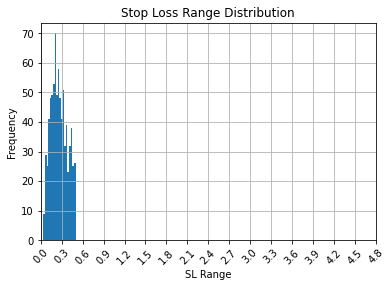

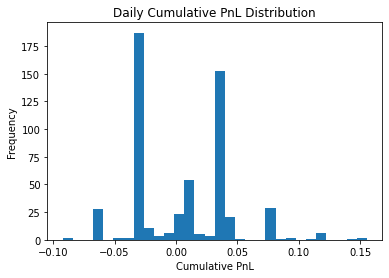

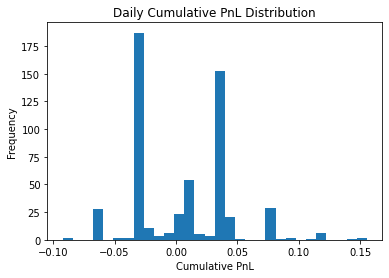

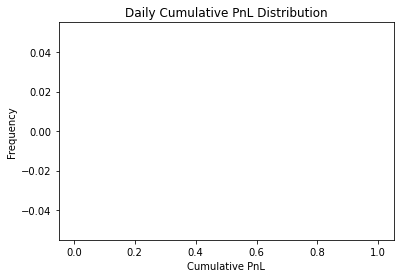

       exit_type          pnl                                         
                         mean            sum          max          min
0    ExitType.SL -1689.440851 -623403.674187  -331.337695 -3765.164408
1  ExitType.TIME   118.050822    4840.083712  2231.635230 -2294.296745
2    ExitType.TP  1916.159849  720476.103324  4569.249344   386.738836


In [12]:
import numpy as np
trades = pd.DataFrame([t.__dict__ for t in result.trades])
trades["pnl_pct"] = trades["pnl"] / result.equity_curve.shift(1).reindex(trades["entry_time"]).values
trade_grouped = trades.groupby('exit_type').agg({'pnl': ['mean', 'sum', 'max', 'min']}).reset_index()
trades["win"] = trades["pnl"] > 0
trade_long = trades[trades['side'] == Side.LONG]
trade_short = trades[trades['side'] == Side.SHORT]
## 連敗計算
trades["loss_streak"] = (trades['win'] == False).astype(int).groupby((trades['win'] != trades['win'].shift()).cumsum()).cumsum()
trade_long['loss_streak'] = (trade_long['win'] == False).astype(int).groupby((trade_long['win'] != trade_long['win'].shift()).cumsum()).cumsum()
trade_short['loss_streak'] = (trade_short['win'] == False).astype(int).groupby((trade_short['win'] != trade_short['win'].shift()).cumsum()).cumsum()

trades["SL_range"] = abs(trades["entry_price"] - trades["sl_price"])/trades["entry_price"] * 100

print("All Trades Max Loss Streaks:", trades['loss_streak'].max())
print("Long Trades Max Loss Streaks:", trade_long['loss_streak'].max())
print("Short Trades Max Loss Streaks:", trade_short['loss_streak'].max())

## 日內累計虧損計算
trades['entry_date'] = trades['entry_time'].dt.date
daily_pnl = trades.groupby('entry_date')['pnl_pct'].sum().reset_index()
daily_pnl['cum_daily_loss'] = daily_pnl['pnl_pct']
trade_long['entry_date'] = trade_long['entry_time'].dt.date
daily_pnl_long = trade_long.groupby('entry_date')['pnl_pct'].sum().reset_index()
daily_pnl_long['cum_daily_loss'] = daily_pnl_long['pnl_pct']
trade_short['entry_date'] = trade_short['entry_time'].dt.date
daily_pnl_short = trade_short.groupby('entry_date')['pnl_pct'].sum().reset_index()
daily_pnl_short['cum_daily_loss'] = daily_pnl_short['pnl_pct']
print("All Trades Max Daily Cumulative Loss:", daily_pnl['cum_daily_loss'].min())
print("Long Trades Max Daily Cumulative Loss:", daily_pnl_long['cum_daily_loss'].min())
print("Long Trades Daily Cumulative < 1.5% Days:", (daily_pnl_long['cum_daily_loss'] < -0.015).sum())
print("Long Trades Daily Cumulative < 2% Days:", (daily_pnl_long['cum_daily_loss'] < -0.02).sum())
print("Short Trades Max Daily Cumulative Loss:", daily_pnl_short['cum_daily_loss'].min())
plt.hist(trades["SL_range"], bins=20)
plt.title("Stop Loss Range Distribution")
plt.xlabel("SL Range")
plt.ylabel("Frequency")
plt.xticks(np.arange(0, 5, 0.3), rotation=45)
plt.grid()
plt.show()

for t in [daily_pnl, daily_pnl_long, daily_pnl_short]:
    plt.hist(t['cum_daily_loss'], bins=30)
    plt.title("Daily Cumulative PnL Distribution")
    plt.xlabel("Cumulative PnL")
    plt.ylabel("Frequency")
    plt.show()


print(trade_grouped)
# plt.hist(sort_pnls, bins=100)
# plt.show()

Max Drawdown: 0.3679494648463366


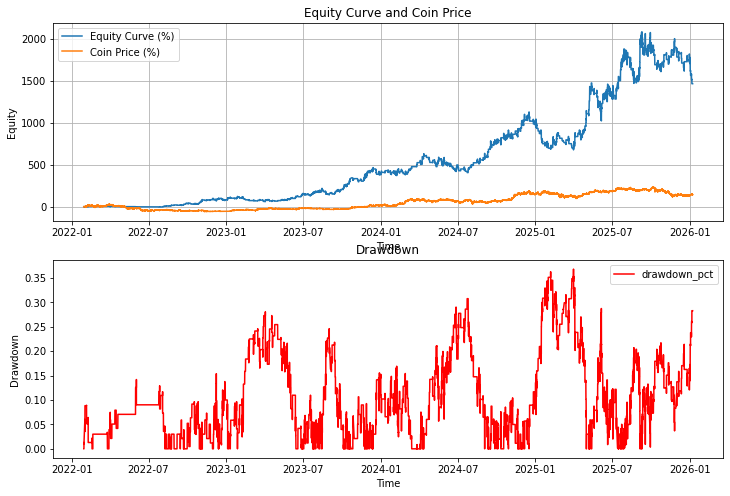

In [55]:
import matplotlib.pyplot as plt
import numpy as np
plot_log_scale = False
coin_curve = df.groupby(df.index).last()['close']
equity_curve = result.equity_curve
plt.figure(figsize=(12, 8))
# subplot equity curve and coin price
plt.subplot(2, 1, 1)
if plot_log_scale ==True:
    log_equity = np.log(equity_curve / equity_curve.iloc[0])
    log_coin = np.log(coin_curve / coin_curve.iloc[0])
    plt.plot(equity_curve.index, log_equity, label='Log Equity Curve')
    plt.plot(coin_curve.index, log_coin, label='Log Coin Price')
else:
    pct_equity = (equity_curve - equity_curve.iloc[0]) / equity_curve.iloc[0] * 100
    pct_coin = (coin_curve - coin_curve.iloc[0]) / coin_curve.iloc[0] * 100
    plt.plot(equity_curve.index, pct_equity, label='Equity Curve (%)')
    plt.plot(coin_curve.index, pct_coin, label='Coin Price (%)')
drawdown_pct = (equity_curve.cummax() - equity_curve) / equity_curve.cummax()
drawdown = equity_curve.cummax() - equity_curve
max_drawdown = drawdown_pct.max()
plt.title('Equity Curve and Coin Price')
plt.xlabel('Time')
plt.ylabel('Equity')
plt.grid()
plt.legend()
print(f"Max Drawdown: {max_drawdown}")
## subplot drawdown
plt.subplot(2, 1, 2)
plt.plot(drawdown_pct.index, drawdown_pct.values, label='drawdown_pct', color='red')
plt.title('Drawdown')
plt.xlabel('Time')
plt.ylabel('Drawdown')
plt.legend()



plt.show()

#### 蒙地卡羅回測

In [ ]:
from backtester.analytics import basic_metrics
from dataclasses import replace
import matplotlib.pyplot as plt
cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0002, slippage_bps=0.0, conservative_intrabar=True)
engine = BacktestEngine(cfg)
rolling_backtest = False
params = ALBreakoutPullback50pctParams(
    break_out_series_n = 3, # BO定義:連續突破K線數
    break_out_n_bars = 40, # 突破區間長度（K線數）
    BO_n_times_atr= 2,
    max_notional_pct = 1, # 最大虧損佔資金比例%
    pullback_ratio= [0.2, 0.3], # 回調比例
    min_sl_range_pct= 0.8,
    n_bar_pivot= 3,  # pivot高低點定義K線數
    min_qty = 0.0001, # 最小BTC下單量
    sl_atr_like = 0.0,  # MVP不做ATR，示範保留欄位
    rr = 1.5,           # TP = SL距離 * rr
    time_exit_bars = 1000,
    allow_side= None,#Side.LONG,
    sizing_equity_base=SizingEquityBase.CURRENT,
)
def core_metrics(result):
    metrics = basic_metrics(result)
    equity_curve = result.equity_curve
    trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
    trade_pnl = trades_df["pnl"]
    # pnl/equity
    trade_pnl_pct = trades_df["pnl"] / equity_curve.shift(1).reindex(trades_df["entry_time"]).values
    trades = len(trades_df)
    win_rate = metrics['win_rate']
    profit_factor = metrics['profit_factor']
    sharpe_ratio = metrics['sharpe_ratio']
    MDD = metrics['max_drawdown']
    mean_pnl_pct = trade_pnl_pct.mean()
    median_pnl_pct = trade_pnl_pct.median()
    p10_pnl_pct = trade_pnl_pct.quantile(0.1)
    p90_pnl_pct = trade_pnl_pct.quantile(0.9)
    return {
        'trades': trades,
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': MDD,
        'mean_pnl_pct': mean_pnl_pct,
        'median_pnl_pct': median_pnl_pct,
        'p10_pnl_pct': p10_pnl_pct,
        'p90_pnl_pct': p90_pnl_pct,
    }
if rolling_backtest == False:
    for fee_rate in [0]:
        strategy = ALBreakoutPullback50pctStrategy(params)
        cfg2 = replace(cfg, fee_rate=fee_rate)
        engine = BacktestEngine(cfg2)
        print(engine.config.fee_rate)
        result = engine.run(df, strategy)
        metrics = basic_metrics(result)
        print(f"=== Fee Rate: {fee_rate*100:.3f}% ===")
        for k, v in metrics.items():
            if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio']:
                # print(f"{k}: {v}")
                pass
        for k, v in core_metrics(result).items():
            print(f"{k}: {v}")
        print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
        trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
        trade_pnl = trades_df["pnl"]
        trades_df["entry_time_hour"] = trades_df["entry_time"].dt.hour
        trade_grouped = trades_df.groupby('entry_time_hour').agg({'pnl': ['mean', 'sum', 'max', 'min', 'count']}).reset_index()
        print(trade_grouped)
        trade_pnl_pct = trades_df["pnl"] / result.equity_curve.shift(1).reindex(trades_df["entry_time"]).values

        plt.hist(trade_pnl_pct, bins=30)
        plt.title(f"Trade PnL Distribution (Fee Rate: {fee_rate})")
        plt.xlabel("PnL")
        plt.ylabel("Frequency")
        plt.show()


NameError: name 'ALBreakoutPullback50pctParams' is not defined

In [ ]:
trades_df["pnl_pct"] = trades_df["pnl"] / result.equity_curve.shift(1).reindex(trades_df["entry_time"]).values

Ruin Rate (MDD < -50%): 74.90%
Average MDD: -56.50%
Worst MDD: -84.26%
Best MDD: -35.38%
Average Max Loss Streak: 11.12
Worst Max Loss Streak: 23
Best Max Loss Streak: 7


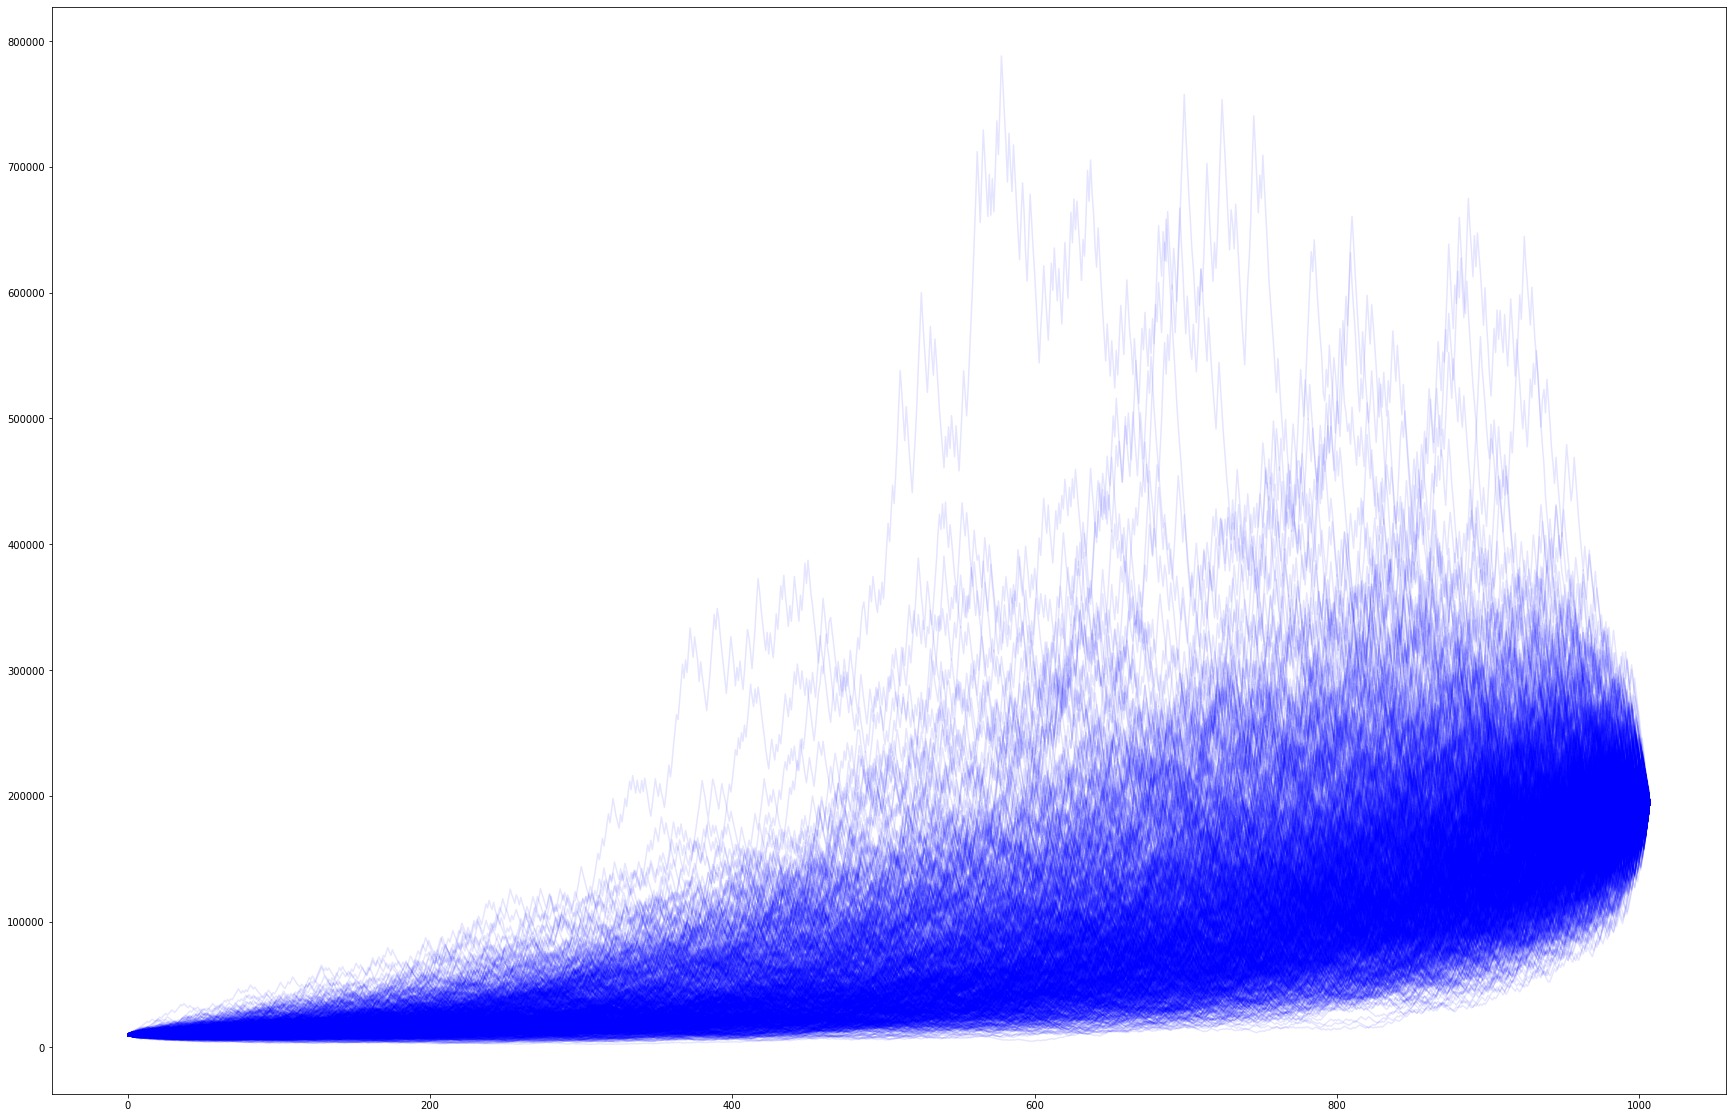

In [ ]:
## randomly shuffle pnl_pct
import numpy as np
random_times = 1000
initial_equity = result.equity_curve.values[0]
monte_carlo_results = {
    "final_return": [],
    "mean_pnl_pct": [],
    "median_pnl_pct": [],
    "MDD": [],
    "Max loss streak": [],
    "equity_curves": [],  # 儲存每次模擬的 equity curve
}
plt.figure(figsize=(30, 20))
for i in range(random_times):
    monte_carlo_df = trades_df.copy()
    random_seed = i  # 每次迭代使用不同的随机种子
    np.random.seed(random_seed)
    monte_carlo_df["pnl_pct"] = np.random.permutation(monte_carlo_df["pnl_pct"].values)
    monte_carlo_df["equity"] = initial_equity * (1 + monte_carlo_df["pnl_pct"]).cumprod()
    final_return = monte_carlo_df["equity"].iloc[-1] - initial_equity
    mean_pnl_pct = monte_carlo_df["pnl_pct"].mean()
    median_pnl_pct = monte_carlo_df["pnl_pct"].median()
    drawdown = monte_carlo_df["equity"].cummax() - monte_carlo_df["equity"]
    drawdown_pct = drawdown / monte_carlo_df["equity"].cummax()
    MDD = drawdown_pct.max()
    monte_carlo_results["final_return"].append(final_return)
    monte_carlo_results["mean_pnl_pct"].append(mean_pnl_pct)
    monte_carlo_results["median_pnl_pct"].append(median_pnl_pct)
    monte_carlo_results["MDD"].append(-MDD)
    # 連敗計算
    monte_carlo_df["win"] = monte_carlo_df["pnl_pct"] > 0
    monte_carlo_df["loss_streak"] = (monte_carlo_df['win'] == False).astype(int).groupby((monte_carlo_df['win'] != monte_carlo_df['win'].shift()).cumsum()).cumsum()
    max_loss_streak = monte_carlo_df['loss_streak'].max()
    monte_carlo_results["Max loss streak"].append(max_loss_streak)
    monte_carlo_results["equity_curves"].append(monte_carlo_df["equity"].values)
    # 細線
    plt.plot(monte_carlo_df["equity"].values, color='blue', alpha=0.1)
monte_carlo_results_df = pd.DataFrame(monte_carlo_results)
ruin_rate = (monte_carlo_results_df["MDD"] < -0.5).mean()
avg_MDD = monte_carlo_results_df["MDD"].mean()
worst_MDD = monte_carlo_results_df["MDD"].min()
best_MDD = monte_carlo_results_df["MDD"].max()
avg_loss_streak = monte_carlo_results_df["Max loss streak"].mean()
worst_loss_streak = monte_carlo_results_df["Max loss streak"].max()
best_loss_streak = monte_carlo_results_df["Max loss streak"].min()
print(f"Ruin Rate (MDD < -50%): {ruin_rate*100:.2f}%")
print(f"Average MDD: {avg_MDD*100:.2f}%")
print(f"Worst MDD: {worst_MDD*100:.2f}%")
print(f"Best MDD: {best_MDD*100:.2f}%")
print(f"Average Max Loss Streak: {avg_loss_streak:.2f}")
print(f"Worst Max Loss Streak: {worst_loss_streak}")
print(f"Best Max Loss Streak: {best_loss_streak}")

plt.show()



#### Rolling 回測

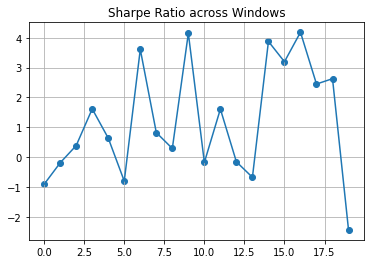

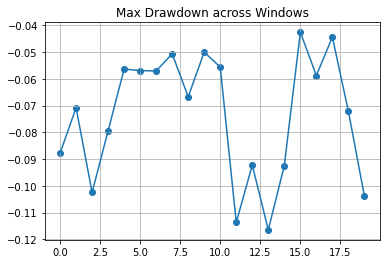

In [ ]:
from backtester.analytics import basic_metrics
from dataclasses import replace
import matplotlib.pyplot as plt
cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0002, slippage_bps=0.0, conservative_intrabar=True)
engine = BacktestEngine(cfg)
rolling_backtest = False
params = TrandingRangeBreakoutParams(
    trading_range_breakout_level_n = 20, # BO定義:連續突破K線數
    er_n = 20, # 突破區間長度（K線數）
    er_ma_n= 5,
    er_threshold= 0.09,
    bbands_n= 20,
    bbands_width_pct_threshold= [1, 3],
    min_cross_bband_mid_count=0,
    
    min_follow_through_bars= 0,
    breakout_bar_BBR_threshold= 0.5,
    min_breakout_penetration_pct= 0,

    equity_max_loss_pct= 1.0,
    min_qty = 0.0001, # 最小下單量
    rr = 2,           # TP = SL距離 * rr
    time_exit_bars = 1000,
    allow_side= Side.LONG,#Side.LONG,
    sizing_equity_base=SizingEquityBase.CURRENT,
)
if rolling_backtest == True:
    all_metrics = {}
    for fee_rate in [0.00005]:
        for window_idx in range(len(splited_train_test_dfs)):
            print(f"=== Window {window_idx+1} ===")
            strategy = TradingRangeBreakoutStrategy(params)
            cfg2 = replace(cfg, fee_rate=fee_rate)
            engine = BacktestEngine(cfg2)
            print(engine.config.fee_rate)
            result = engine.run(splited_dfs[window_idx], strategy)
            metrics = basic_metrics(result)
            print(f"=== Fee Rate: {fee_rate} ===")
            for k, v in metrics.items():
                if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio', 'avg_win_held_bars', 'avg_loss_held_bars']:
                    # print(f"{k}: {v}")
                    pass
            for k, v in core_metrics(result).items():
                print(f"{k}: {v}")
                all_metrics.setdefault(k, []).append(v)
            print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
            trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
            trade_pnl = trades_df["pnl"]
            trades_df["entry_time_hour"] = trades_df["entry_time"].dt.hour
            trade_grouped = trades_df.groupby('entry_time_hour').agg({'pnl': ['mean', 'sum', 'max', 'min', 'count']}).reset_index()
            print(trade_grouped)
            # plt.hist(trade_pnl, bins=30)
            # plt.title(f"Trade PnL Distribution (Fee Rate: {fee_rate})")
            # plt.xlabel("PnL")
            # plt.ylabel("Frequency")
            # plt.show()
    all_metrics_df = pd.DataFrame(all_metrics)
    all_metrics_df.describe() 

plt.scatter(all_metrics_df.index, all_metrics_df['sharpe_ratio'])
plt.plot(all_metrics_df.index, all_metrics_df['sharpe_ratio'])
plt.title("Sharpe Ratio across Windows")
plt.grid()
plt.show()

plt.scatter(all_metrics_df.index, all_metrics_df['max_drawdown'])
plt.plot(all_metrics_df.index, all_metrics_df['max_drawdown'])
plt.title("Max Drawdown across Windows")
plt.grid()
plt.show()

### Params Heatmap

In [43]:
param_values = np.arange(0.2, 1.7, 0.2)
# add one more line for 1.5
param_values = np.append(param_values, 1.5)
param_values

array([0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.5])

In [49]:
from backtester.analytics import basic_metrics
from dataclasses import replace
import matplotlib.pyplot as plt
import numpy as np

strategy_name = "strong breakout" # SBO: Strong Breakout, TRBO: Trading Range Breakout
rolling_backtest = False
if strategy_name == "strong breakout":
    cfg = BacktestConfig(initial_cash=10000, fee_rate=0.00005, slippage_bps=0.0, conservative_intrabar=True)
    params = StrongBreakoutParams(
        BBR_thresholds =  (0.45, 0.65),
        close_loc_thresholds = (0.5, 0.7),
        push_thresholds = (0.5, 1.0, 1.5),
        overlap_thresholds = (0.3, 0.5),
        break_out_n_bars=20,

        run_score_threshold = 10.0,
        session="Asian",  # "Asian", "EU", "US", None

        max_equity_loss_pct = 1.5,
        min_qty = 0.001,
        min_sl_pct = 0.5,

        rr = 1.3,         # TP = SL距離 * rr
        time_exit_bars = 50,
        allow_side = Side.LONG,  # None表示雙向進出場，Side.LONG表示只做多，Side.SHORT表示只做空
        sizing_equity_base = SizingEquityBase.CURRENT,
    )
    strategy = StrongBreakoutStrategy(params)
elif strategy_name == "trading range breakout":
    cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0002, slippage_bps=0.0, conservative_intrabar=True)
    params = TrandingRangeBreakoutParams(
        trading_range_breakout_level_n=20,
        er_n=20,
        er_ma_n=5,
        er_threshold=0.09,
        bbands_n=20,
        bbands_width_pct_threshold=[1, 3],
        min_cross_bband_mid_count=0,
        min_follow_through_bars=0,

        breakout_bar_BBR_threshold=0.5,
        min_breakout_penetration_pct=0,
        
        equity_max_loss_pct=1.0,
        min_qty=0.0001,

        sl_chosen_by="TR_low",
        # tp_based_by="entry_price",
        rr=2,
        time_exit_bars=1000,
        allow_side=Side.LONG,
        sizing_equity_base=SizingEquityBase.CURRENT
    )
    strategy = TradingRangeBreakoutStrategy(params)

param_name = "min_sl_pct"
param_values = np.arange(0.2, 1.7, 0.2)
param_values = np.append(param_values, 10)
# param_values = [0.5]

all_metrics = {}
if rolling_backtest == False:
    for param_value in param_values:
        if type(param_value) == float:
            param_value = round(param_value, 2)
        params = replace(params, **{param_name: param_value})
        if strategy_name == "strong breakout":
            strategy = StrongBreakoutStrategy(params)
        elif strategy_name == "trading range breakout":
            strategy = TradingRangeBreakoutStrategy(params)
        engine = BacktestEngine(cfg)
        result = engine.run(df, strategy)
        metrics = basic_metrics(result)
        print(f"=== {param_name}: {param_value} ===")
        all_metrics.setdefault(param_name, []).append(param_value)
        for k, v in metrics.items():
            if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio']:
                all_metrics.setdefault(k, []).append(v)
                print(f"{k}: {v}")
        print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
        all_metrics.setdefault('final_profit', []).append(result.equity_curve.values[-1] - result.equity_curve.values[0])
        trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
        trade_pnl = trades_df["pnl"]


    all_metrics_df = pd.DataFrame(all_metrics)
print(all_metrics_df)

=== min_sl_pct: 0.2 ===
trades: 289.0
win_rate: 0.4913494809688581
profit_factor: 1.1386104024063026
max_drawdown: -0.16122826192927484
sharpe_ratio: 0.2968372446196235
total_days: 1439.0
final profit: 1587.5102953786245
=== min_sl_pct: 0.4 ===
trades: 669.0
win_rate: 0.5037369207772795
profit_factor: 1.2136816297491915
max_drawdown: -0.2143647258845335
sharpe_ratio: 1.0232199652598217
total_days: 1439.0
final profit: 14792.445491651637
=== min_sl_pct: 0.6000000000000001 ===
trades: 849.0
win_rate: 0.4911660777385159
profit_factor: 1.1530725012901846
max_drawdown: -0.25743667714659896
sharpe_ratio: 0.8813745718935978
total_days: 1439.0
final profit: 13442.290606504066
=== min_sl_pct: 0.8 ===
trades: 944.0
win_rate: 0.4830508474576271
profit_factor: 1.1301405574645238
max_drawdown: -0.25537740345169707
sharpe_ratio: 0.7629996831307151
total_days: 1439.0
final profit: 11236.396060923427
=== min_sl_pct: 1.0 ===
trades: 981.0
win_rate: 0.47604485219164117
profit_factor: 1.1112103860069764


In [51]:
all_metrics_df.to_excel(rf"C:\Users\User\Desktop\JJproject\策略\{strategy_name}\參數分析\BTC_5m_trades_V4_asian_session_{param_name}\tune_{param_name}_(fee_rate_{cfg.fee_rate}_slippage_{cfg.slippage_bps}).xlsx")

0    289.0
Name: trades, dtype: float64
1    669.0
Name: trades, dtype: float64
2    849.0
Name: trades, dtype: float64
3    944.0
Name: trades, dtype: float64
4    981.0
Name: trades, dtype: float64
5    1001.0
Name: trades, dtype: float64
6    1013.0
Name: trades, dtype: float64
7    1025.0
Name: trades, dtype: float64
8    1053.0
Name: trades, dtype: float64


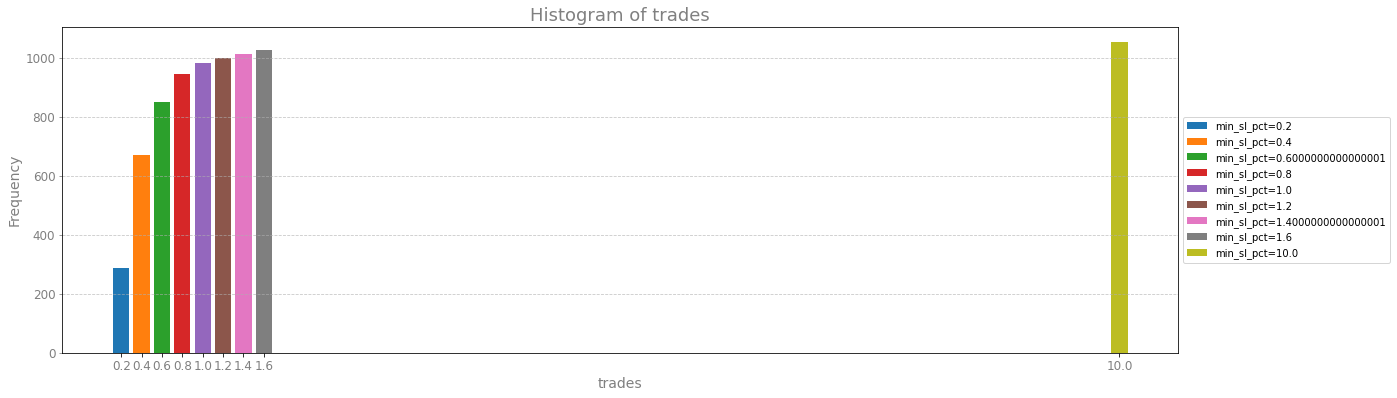

0    0.491349
Name: win_rate, dtype: float64
1    0.503737
Name: win_rate, dtype: float64
2    0.491166
Name: win_rate, dtype: float64
3    0.483051
Name: win_rate, dtype: float64
4    0.476045
Name: win_rate, dtype: float64
5    0.474525
Name: win_rate, dtype: float64
6    0.476802
Name: win_rate, dtype: float64
7    0.478049
Name: win_rate, dtype: float64
8    0.482431
Name: win_rate, dtype: float64


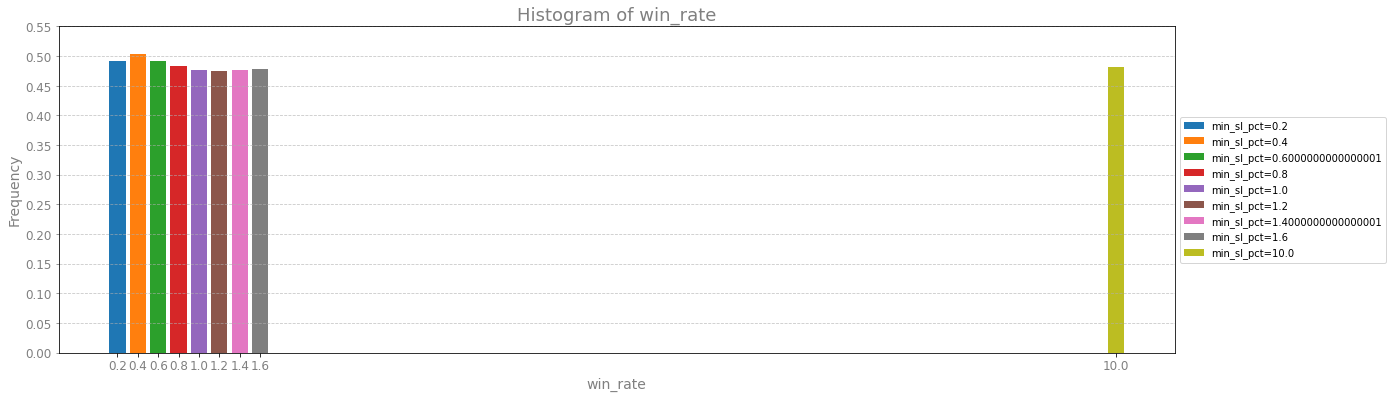

0    1.13861
Name: profit_factor, dtype: float64
1    1.213682
Name: profit_factor, dtype: float64
2    1.153073
Name: profit_factor, dtype: float64
3    1.130141
Name: profit_factor, dtype: float64
4    1.11121
Name: profit_factor, dtype: float64
5    1.109098
Name: profit_factor, dtype: float64
6    1.115508
Name: profit_factor, dtype: float64
7    1.115714
Name: profit_factor, dtype: float64
8    1.12555
Name: profit_factor, dtype: float64


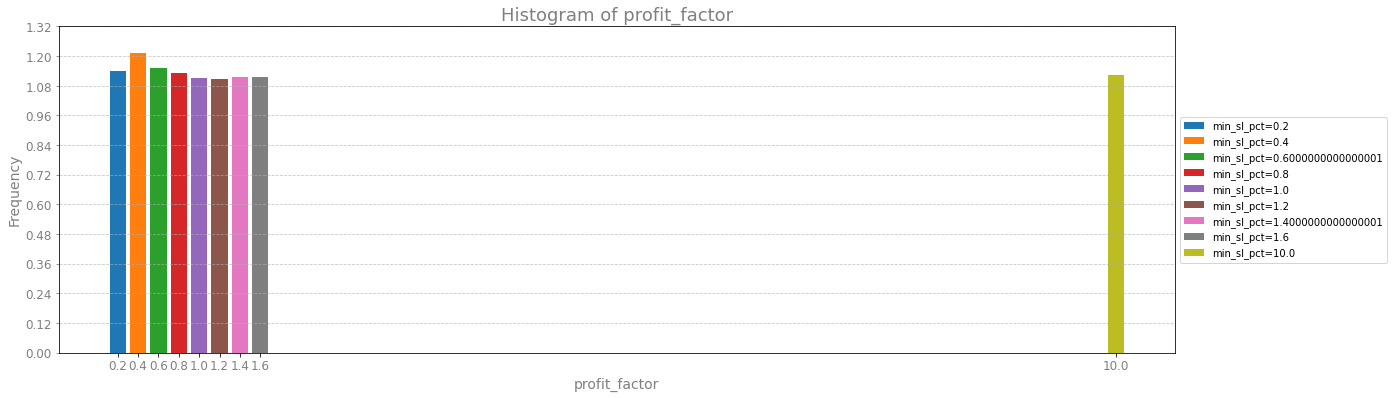

0   -0.161228
Name: max_drawdown, dtype: float64
1   -0.214365
Name: max_drawdown, dtype: float64
2   -0.257437
Name: max_drawdown, dtype: float64
3   -0.255377
Name: max_drawdown, dtype: float64
4   -0.266294
Name: max_drawdown, dtype: float64
5   -0.266294
Name: max_drawdown, dtype: float64
6   -0.272018
Name: max_drawdown, dtype: float64
7   -0.305211
Name: max_drawdown, dtype: float64
8   -0.292074
Name: max_drawdown, dtype: float64


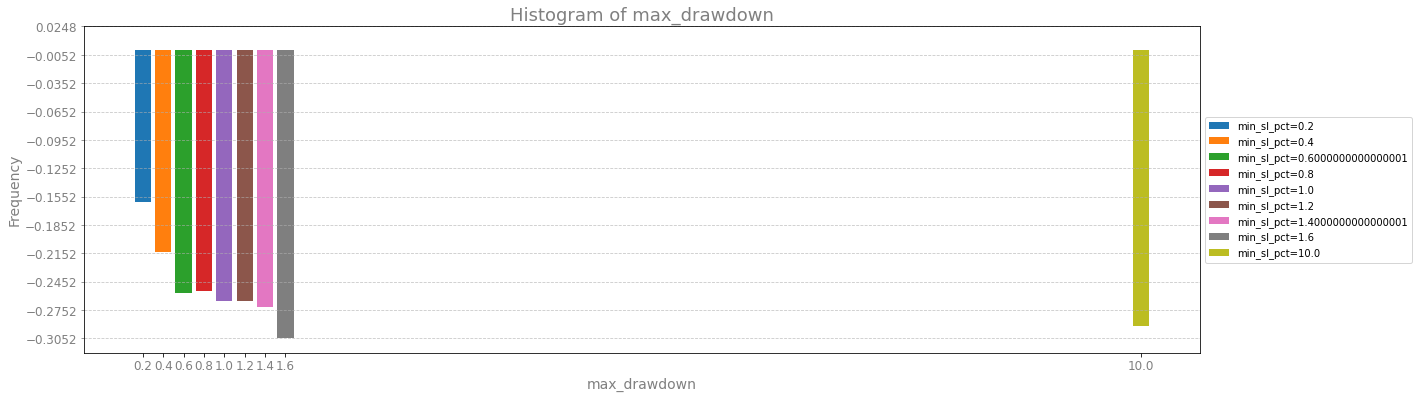

0    0.296837
Name: sharpe_ratio, dtype: float64
1    1.02322
Name: sharpe_ratio, dtype: float64
2    0.881375
Name: sharpe_ratio, dtype: float64
3    0.763
Name: sharpe_ratio, dtype: float64
4    0.618036
Name: sharpe_ratio, dtype: float64
5    0.599152
Name: sharpe_ratio, dtype: float64
6    0.651287
Name: sharpe_ratio, dtype: float64
7    0.664567
Name: sharpe_ratio, dtype: float64
8    0.743967
Name: sharpe_ratio, dtype: float64


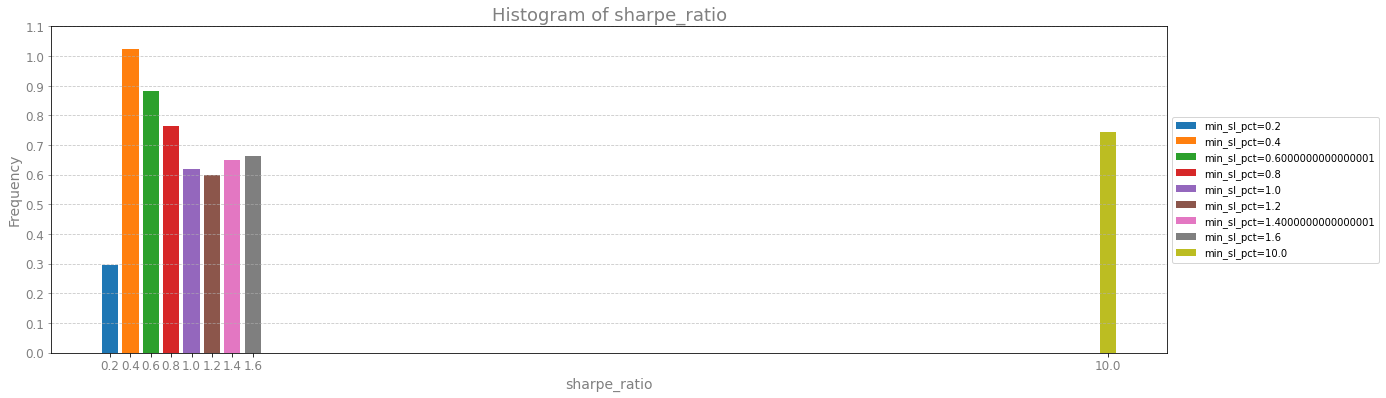

0    1439.0
Name: total_days, dtype: float64
1    1439.0
Name: total_days, dtype: float64
2    1439.0
Name: total_days, dtype: float64
3    1439.0
Name: total_days, dtype: float64
4    1439.0
Name: total_days, dtype: float64
5    1439.0
Name: total_days, dtype: float64
6    1439.0
Name: total_days, dtype: float64
7    1439.0
Name: total_days, dtype: float64
8    1439.0
Name: total_days, dtype: float64


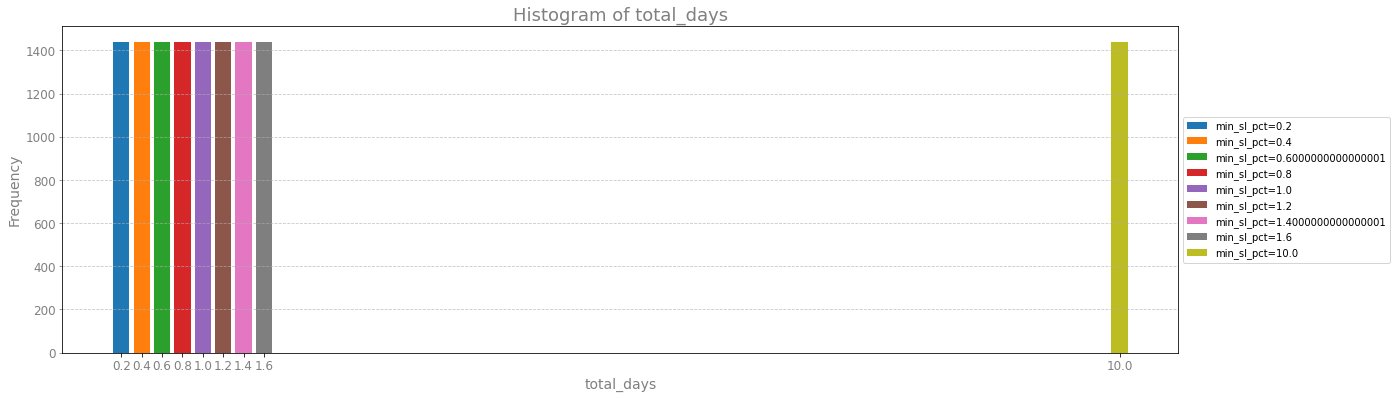

0    1587.510295
Name: final_profit, dtype: float64
1    14792.445492
Name: final_profit, dtype: float64
2    13442.290607
Name: final_profit, dtype: float64
3    11236.396061
Name: final_profit, dtype: float64
4    8066.153791
Name: final_profit, dtype: float64
5    7730.249924
Name: final_profit, dtype: float64
6    8902.240771
Name: final_profit, dtype: float64
7    9185.193454
Name: final_profit, dtype: float64
8    11121.281413
Name: final_profit, dtype: float64


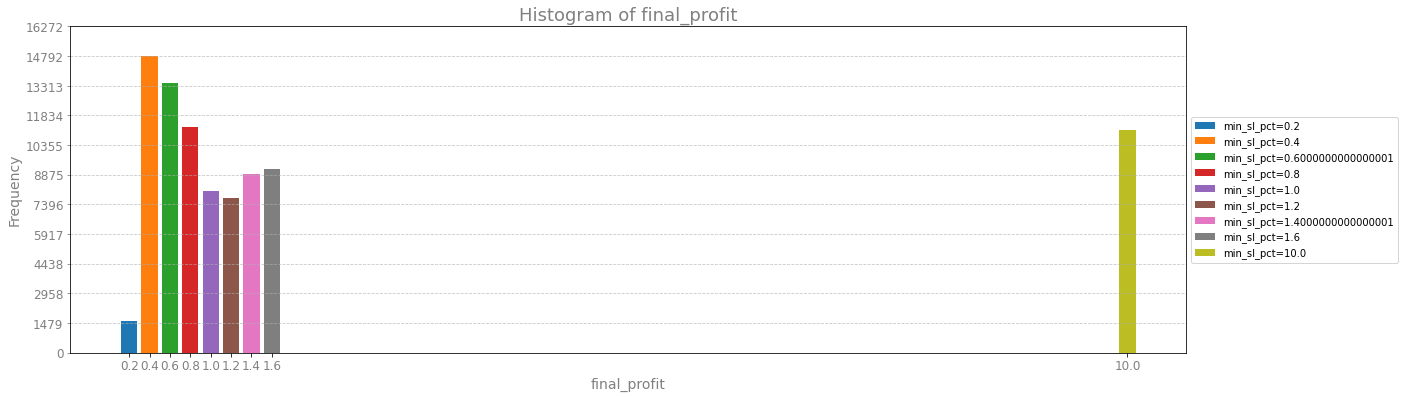

In [52]:
import matplotlib.pyplot as plt

## Draw

for metric in all_metrics_df.columns[1:]:
    # if 
    plt.figure(figsize=(20, 6))
    if all_metrics_df[param_name].dtype == object:
        width = 0.4
    else:
        width = all_metrics_df[param_name].diff().min() * 0.8 if len(all_metrics_df[param_name].unique()) > 1 else 0.4
    for i, param_value in enumerate(all_metrics_df[param_name].unique()):
        subset = all_metrics_df[all_metrics_df[param_name] == param_value]
        # plot bar for each metric
        print(subset[metric])
        if subset[metric].empty:
            height = 0
        else:
            height = subset[metric].values[0]
        if all_metrics_df[param_name].dtype == object:
            bar_x = i

        else:
            bar_x = param_value
        
        
        plt.bar(bar_x, height, width=width, label=f"{param_name}={param_value}")
    plt.title(f"Histogram of {metric}", color='gray', fontsize=18)
    plt.xlabel(metric, color='gray', fontsize=14)
    if all_metrics_df[param_name].dtype == object:
        plt.xticks([i for i in range(len(all_metrics_df[param_name].unique()))], all_metrics_df[param_name].unique(), fontsize=12, color='gray')
    else:
        plt.xticks(all_metrics_df[param_name].unique(), fontsize=12, color='gray')
    plt.ylabel("Frequency", color='gray', fontsize=14)
    plt.tick_params(axis='y', labelsize=12, colors='gray')
    if metric not in ['trades', 'total_days'] and all_metrics_df[metric].dtype != object:
        max_value = max(all_metrics_df[metric].max(), 0)
        min_value = min(all_metrics_df[metric].min(), 0)
        step = round((max_value - min_value) / 10, 2) if max_value != min_value else 1
        plt.yticks(np.arange(min_value, max_value + step, step))
    # right side legend with 1 column
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
    # add -- grid
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig(rf"C:\Users\User\Desktop\JJproject\策略\{strategy_name}\參數分析\BTC_5m_trades_V4_asian_session_{param_name}\{metric}_vs_{param_name}_(fee_rate_{cfg.fee_rate}_slippage_{cfg.slippage_bps}).png", dpi=300, bbox_inches='tight')
    plt.show()